# Chapter 9 — Hypothesis Testing (One Sample)

Null hypotheses, error types, and what a p-value really measures.

| Section | What it covers |
|---|---|
| 9.1 | Hypotheses and error types |
| 9.2 | The p-value |
| 9.3 | The full test, honestly run |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Hypothesis Testing (One Sample)](https://khh-aka-lucifer.github.io/statLab/chapters/hypothesis-testing/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## A claim, and data that might doubt it

A **hypothesis test** starts with a claim you are willing to doubt, the **null hypothesis** $H_0$.
You collect data, work out how surprising it would be if the claim were true, and reject the claim
when the surprise is large enough.

Suppose a field guide states that Adelie penguins average 3600 g. We have measurements. Does the
guide hold up?

In [2]:
penguins = pd.read_csv(DATA / "penguins.csv")
adelie = penguins.loc[penguins["species"] == "Adelie", "body_mass_g"].dropna().to_numpy()

claimed = 3600
print(f"the guide says      mu = {claimed} g")
print(f"our {len(adelie)} birds average  {adelie.mean():.1f} g   (sd {adelie.std(ddof=1):.1f} g)")
print(f"difference           {adelie.mean() - claimed:+.1f} g")

the guide says      mu = 3600 g
our 151 birds average  3700.7 g   (sd 458.6 g)
difference           +100.7 g


A hundred grams heavier. But a sample mean is always a bit off, so the question is whether 100 g is
more than sampling noise can comfortably explain.

## 9.1 Hypotheses and error types

$H_0: \mu = 3600$ is the claim under doubt. $H_1: \mu \ne 3600$ is what we would conclude instead.
We draw a sample and reject $H_0$ if the mean lands far enough from 3600.

Two things can go wrong, and they trade off against each other.

Rejecting a true $H_0$ is a **Type I error**, with probability $\alpha$. Failing to reject when the
effect is real is a **Type II error**, with probability $\beta$. The **power** of a test is
$1 - \beta$, the chance of catching a real effect.

In [3]:
n, alpha = 40, 0.05
sigma_known = adelie.std(ddof=1)

# the world where H0 is true: masses really do average 3600
cutoff = stats.norm.ppf(1 - alpha / 2) * sigma_known / np.sqrt(n)
print(f"with n = {n}, we reject if the sample mean is more than {cutoff:.1f} g from {claimed}")
print(f"so reject below {claimed - cutoff:.1f} g or above {claimed + cutoff:.1f} g")

with n = 40, we reject if the sample mean is more than 142.1 g from 3600
so reject below 3457.9 g or above 3742.1 g


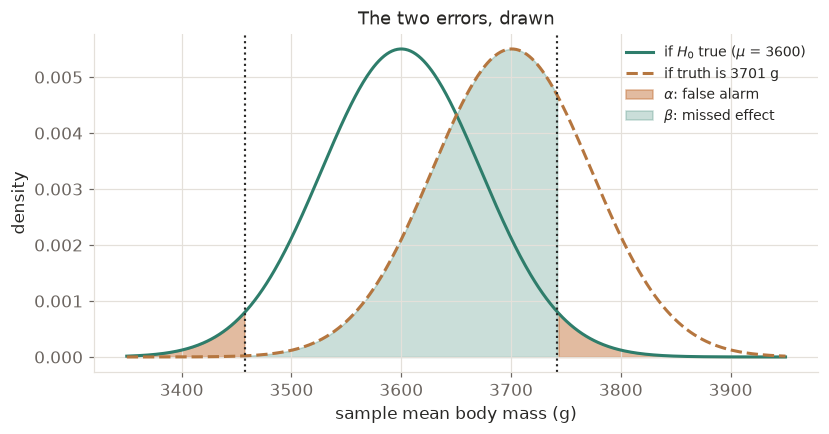

power at n = 40: 0.284   (so beta = 0.716)


In [4]:
truth = adelie.mean()            # pretend this is the real mean
grid = np.linspace(3350, 3950, 500)
se = sigma_known / np.sqrt(n)

fig, ax = plt.subplots(figsize=(8.5, 4))
h0 = stats.norm.pdf(grid, claimed, se)
h1 = stats.norm.pdf(grid, truth, se)
ax.plot(grid, h0, color=C["accent"], lw=2, label=rf"if $H_0$ true ($\mu$ = {claimed})")
ax.plot(grid, h1, color=C["cat2"], lw=2, ls="--", label=f"if truth is {truth:.0f} g")

lo, hi = claimed - cutoff, claimed + cutoff
tail = (grid <= lo) | (grid >= hi)
ax.fill_between(grid[grid >= hi], h0[grid >= hi], color=C["warn"], alpha=0.45,
                label=r"$\alpha$: false alarm")
ax.fill_between(grid[grid <= lo], h0[grid <= lo], color=C["warn"], alpha=0.45)
middle = (grid > lo) & (grid < hi)
ax.fill_between(grid[middle], h1[middle], color=C["accent"], alpha=0.25,
                label=r"$\beta$: missed effect")

for edge in (lo, hi):
    ax.axvline(edge, color=C["ink"], lw=1.4, ls=":")

ax.set_xlabel("sample mean body mass (g)"); ax.set_ylabel("density")
ax.set_title("The two errors, drawn")
ax.legend(fontsize=9)
plt.show()

power = 1 - (stats.norm.cdf(hi, truth, se) - stats.norm.cdf(lo, truth, se))
print(f"power at n = {n}: {power:.3f}   (so beta = {1 - power:.3f})")

Shrink $\alpha$ by moving the cutoffs outwards and the orange tails shrink, but the blue overlap
grows, so $\beta$ rises. You cannot reduce both by fiddling with the cutoff. The only ways to shrink
both at once are a larger sample, which narrows both curves, or a larger real effect, which pulls
them apart.

In [5]:
for n_try in [10, 20, 40, 80, 160]:
    se_try = sigma_known / np.sqrt(n_try)
    edge = stats.norm.ppf(1 - alpha / 2) * se_try
    pw = 1 - (stats.norm.cdf(claimed + edge, truth, se_try) - stats.norm.cdf(claimed - edge, truth, se_try))
    print(f"n = {n_try:3d}   power = {pw:.3f}")

n =  10   power = 0.107
n =  20   power = 0.166
n =  40   power = 0.284
n =  80   power = 0.501
n = 160   power = 0.793


In [ ]:
# Your turn.
# Keep n = 40 but change alpha to 0.01 and then to 0.10.
# Recompute the cutoff and the power each time.
# Make a small table of alpha against power, and describe the trade in one comment line.

...

## 9.2 The p-value

The **p-value** answers one question. If $H_0$ were true, how often would a sample land at least
this far from the claim?

It is not the probability that $H_0$ is true. It is a property of the data given the claim, not of
the claim given the data, and mixing those up is the most common mistake in applied statistics.

In [6]:
t_stat, p_value = stats.ttest_1samp(adelie, claimed)

print(f"t = {t_stat:.4f}")
print(f"p = {p_value:.6f}")
print(f"df = {len(adelie) - 1}")

t = 2.6974
p = 0.007787
df = 150


In [7]:
# the same number, computed from the definition
n = len(adelie)
se = adelie.std(ddof=1) / np.sqrt(n)
t_by_hand = (adelie.mean() - claimed) / se
p_by_hand = 2 * (1 - stats.t.cdf(abs(t_by_hand), n - 1))

print(f"t by hand = {t_by_hand:.4f}")
print(f"p by hand = {p_by_hand:.6f}   <- 2 x the tail beyond |t|, because the test is two-sided")

t by hand = 2.6974
p by hand = 0.007787   <- 2 x the tail beyond |t|, because the test is two-sided


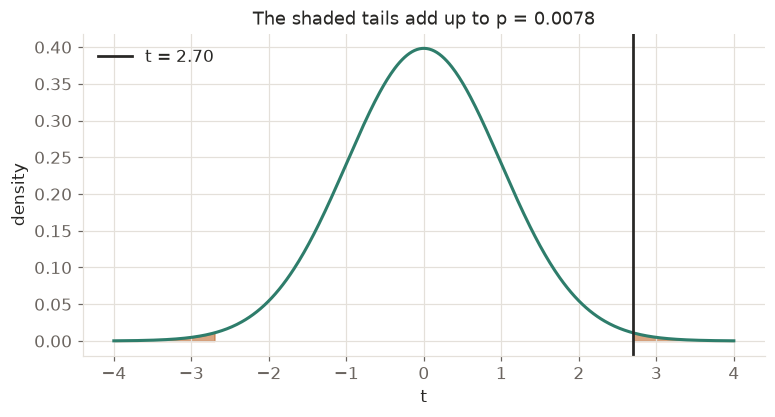

In [8]:
grid = np.linspace(-4, 4, 500)
density = stats.t.pdf(grid, n - 1)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(grid, density, color=C["accent"], lw=2)
for side in [grid <= -abs(t_by_hand), grid >= abs(t_by_hand)]:
    ax.fill_between(grid[side], density[side], color=C["warn"], alpha=0.6)
ax.axvline(t_by_hand, color=C["ink"], lw=1.8, label=f"t = {t_by_hand:.2f}")

ax.set_xlabel("t"); ax.set_ylabel("density")
ax.set_title(f"The shaded tails add up to p = {p_by_hand:.4f}")
ax.legend()
plt.show()

### What p-values look like when nothing is happening

Here is the fact that makes p-values make sense. When $H_0$ is exactly true, the p-value is
**uniform** on 0 to 1. Every value is equally likely, and 5 % of the time you get one below 0.05 and
declare a discovery that is not there.

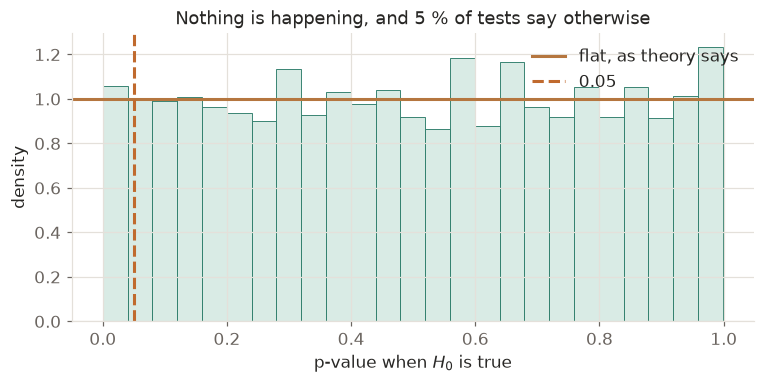

share below 0.05: 0.0520


In [9]:
true_mean = adelie.mean()
null_ps = np.array([stats.ttest_1samp(rng.choice(adelie, 30, replace=True), true_mean).pvalue
                    for _ in range(4000)])

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(null_ps, bins=25, density=True, color=C["accent_soft"], edgecolor=C["accent"], linewidth=0.6)
ax.axhline(1.0, color=C["cat2"], lw=2, label="flat, as theory says")
ax.axvline(0.05, color=C["warn"], lw=2, ls="--", label="0.05")

ax.set_xlabel("p-value when $H_0$ is true"); ax.set_ylabel("density")
ax.set_title("Nothing is happening, and 5 % of tests say otherwise")
ax.legend()
plt.show()

print(f"share below 0.05: {(null_ps < 0.05).mean():.4f}")

In [ ]:
# Your turn.
# Repeat the experiment with a FALSE null: test against 3600 while sampling from the real Adelie data.
# 1. Plot the p-values. Are they still flat?
# 2. What share fall below 0.05? That share is the power of the test at n = 30.

...

## 9.3 The full test, honestly run

A complete test written out, with the decision and, just as importantly, the size of the effect.
A p-value tells you whether you can rule out chance. It does not tell you whether the difference
matters, and only an interval and a bit of judgement can do that.

In [10]:
def one_sample_report(data, claim, alpha=0.05, label="values"):
    n = len(data)
    xbar, s = data.mean(), data.std(ddof=1)
    se = s / np.sqrt(n)
    t_stat = (xbar - claim) / se
    p = 2 * (1 - stats.t.cdf(abs(t_stat), n - 1))
    t_star = stats.t.ppf(1 - alpha / 2, n - 1)
    lo, hi = xbar - t_star * se, xbar + t_star * se

    print(f"H0: mu = {claim}          H1: mu != {claim}          alpha = {alpha}")
    print(f"n = {n}   mean = {xbar:.2f}   s = {s:.2f}   SE = {se:.2f}")
    print(f"t = {t_stat:.4f} on {n-1} df")
    print(f"p = {p:.6f}")
    print(f"{1-alpha:.0%} CI for mu: ({lo:.2f}, {hi:.2f})")
    print()
    print("Decision: " + ("reject H0" if p < alpha else "do not reject H0"))
    print(f"Effect:   the mean is {xbar - claim:+.1f} {label} from the claim, "
          f"which is {abs(xbar-claim)/s:.2f} sample standard deviations.")
    return {"t": t_stat, "p": p, "ci": (lo, hi)}

result = one_sample_report(adelie, 3600, label="g")

H0: mu = 3600          H1: mu != 3600          alpha = 0.05
n = 151   mean = 3700.66   s = 458.57   SE = 37.32
t = 2.6974 on 150 df
p = 0.007787
95% CI for mu: (3626.93, 3774.40)

Decision: reject H0
Effect:   the mean is +100.7 g from the claim, which is 0.22 sample standard deviations.


We reject the field guide's 3600 g. The interval says the true Adelie mean is somewhere around
3640 to 3775 g, so the guide is low, but only by about a hundred grams, which is a quarter of a
standard deviation. Statistically detectable and biologically minor. Both halves of that sentence
matter and the p-value only gave us the first.

Now the same machinery on a claim that survives.

In [11]:
_ = one_sample_report(adelie, 3700, label="g")

H0: mu = 3700          H1: mu != 3700          alpha = 0.05
n = 151   mean = 3700.66   s = 458.57   SE = 37.32
t = 0.0177 on 150 df
p = 0.985865
95% CI for mu: (3626.93, 3774.40)

Decision: do not reject H0
Effect:   the mean is +0.7 g from the claim, which is 0.00 sample standard deviations.


Same data, same test, different claim, and now we cannot reject. Notice that 3700 sits inside the
confidence interval from before and 3600 does not. That is not a coincidence. A two-sided test at
level $\alpha$ rejects exactly the values outside the $1-\alpha$ interval, so the interval is the
set of claims the data does not reject.

In [ ]:
# Your turn.
# Use one_sample_report on Gentoo penguin body mass against a claimed 5000 g.
# Then find, by trying values, the smallest claim you can NOT reject and the largest.
# Compare that pair against the 95% confidence interval the function prints.

gentoo = penguins.loc[penguins["species"] == "Gentoo", "body_mass_g"].dropna().to_numpy()
...

## Exercises

1. **One tail or two.** Redo the 3600 g test as a one-sided test of $H_1: \mu > 3600$. The p-value
   halves. Explain why choosing the direction after seeing the data is cheating.

2. **The interval and the test agree.** For Chinstrap penguins, compute the 95 % interval, then run
   two-sided tests against twenty claims spread across and beyond it. Confirm that you reject exactly
   the claims outside the interval.

3. **p-hacking, demonstrated.** Take Adelie mass and test it against its own true mean, but run the
   test separately on males, females, each island, and each year. With enough subgroups you will find
   a p below 0.05 on data where nothing is happening. Count how many tests it took.

4. **Power planning.** You want 80 % power to detect a 50 g difference in Adelie mass at
   $\alpha = 0.05$. Find the required $n$ by simulation. Then look up `statsmodels`' power functions
   and compare.

5. **Assumptions.** The t-test assumes roughly normal data or a decent sample size. Run it on Titanic
   `fare`, which is violently skewed, at $n = 10$. Simulate under a true null and check whether the
   false alarm rate really is 5 %.

## What you should take away

A test asks how surprising your data would be if a claim were true, and the p-value is that surprise
expressed as a probability. It is not the probability the claim is true.

The two errors trade off, and only more data or a bigger real effect improves both. When nothing is
happening, p-values are uniform, which is why 5 % of honest tests on nothing will still shout. And a
significant result with a tiny effect size is a real thing that does not matter, so always report
the interval next to the p-value.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*